In [1]:
import tensorflow as tf
(x_train,y_train),(x_test,y_test)= tf.keras.datasets.mnist.load_data()

In [2]:
x_train.shape

(60000, 28, 28)

In [3]:
x_test.shape

(10000, 28, 28)

In [4]:
x_train = x_train.reshape(x_train.shape[0],28,28,1)
x_test = x_test.reshape(x_test.shape[0],28,28,1)
input_shape = (28,28,1)

In [5]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [6]:
x_train /= 255 # mandatory step to normalize the pixel of image from 0 -255 to 0-1 range
x_test /= 255

In [20]:
#model creation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D

model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

In [21]:
#model compile
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics = ['accuracy'])

In [22]:
#fitting the model
history = model.fit(x=x_train,y=y_train, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 32s 16ms/step - loss: 0.1598 - accuracy: 0.9505
Epoch 2/10
1875/1875 [==============================] - 28s 15ms/step - loss: 0.0554 - accuracy: 0.9835
Epoch 3/10
1875/1875 [==============================] - 29s 15ms/step - loss: 0.0400 - accuracy: 0.9876
Epoch 4/10
1875/1875 [==============================] - 28s 15ms/step - loss: 0.0324 - accuracy: 0.9897
Epoch 5/10
1875/1875 [==============================] - 31s 17ms/step - loss: 0.0268 - accuracy: 0.9912
Epoch 6/10
1875/1875 [==============================] - 29s 15ms/step - loss: 0.0213 - accuracy: 0.9932
Epoch 7/10
1875/1875 [==============================] - 31s 16ms/step - loss: 0.0167 - accuracy: 0.9946
Epoch 8/10
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0153 - accuracy: 0.9952
Epoch 9/10
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0140 - accuracy: 0.9951
Epoch 10/10
1875/1875 [==============================] - 30s 16m

In [10]:
model.evaluate(x_test,y_test)

313/313 [==============================] - 2s 5ms/step - loss: 0.0541 - accuracy: 0.9860


[0.05412128195166588, 0.9860000014305115]

In [28]:
#predicting the labels_digit
y_predict = model.predict(x_test)
y_predict

313/313 [==============================] - 2s 7ms/step


array([[9.96193197e-11, 1.39282197e-10, 6.91656715e-12, ...,
        1.00000000e+00, 8.19862434e-14, 9.13832787e-10],
       [3.06923896e-11, 5.70381520e-10, 1.00000000e+00, ...,
        5.07210783e-15, 3.03071993e-13, 6.63535543e-19],
       [5.33207972e-13, 1.00000000e+00, 3.35638428e-09, ...,
        2.53093368e-09, 4.14500413e-11, 4.01941826e-13],
       ...,
       [9.47220603e-26, 1.70278302e-13, 6.63307758e-19, ...,
        4.25546110e-17, 3.78974357e-15, 4.20645981e-14],
       [6.39086412e-16, 1.04261898e-17, 1.00583365e-24, ...,
        1.03173866e-17, 1.42275365e-08, 4.88245292e-15],
       [5.90851136e-15, 1.34864450e-13, 7.85122039e-15, ...,
        3.14786385e-24, 1.13691717e-12, 2.25368646e-18]], dtype=float32)

In [30]:
#Here we get the index of maximum value in the encoded vector.
y_predicts = np.argmax(y_predict,axis=1)

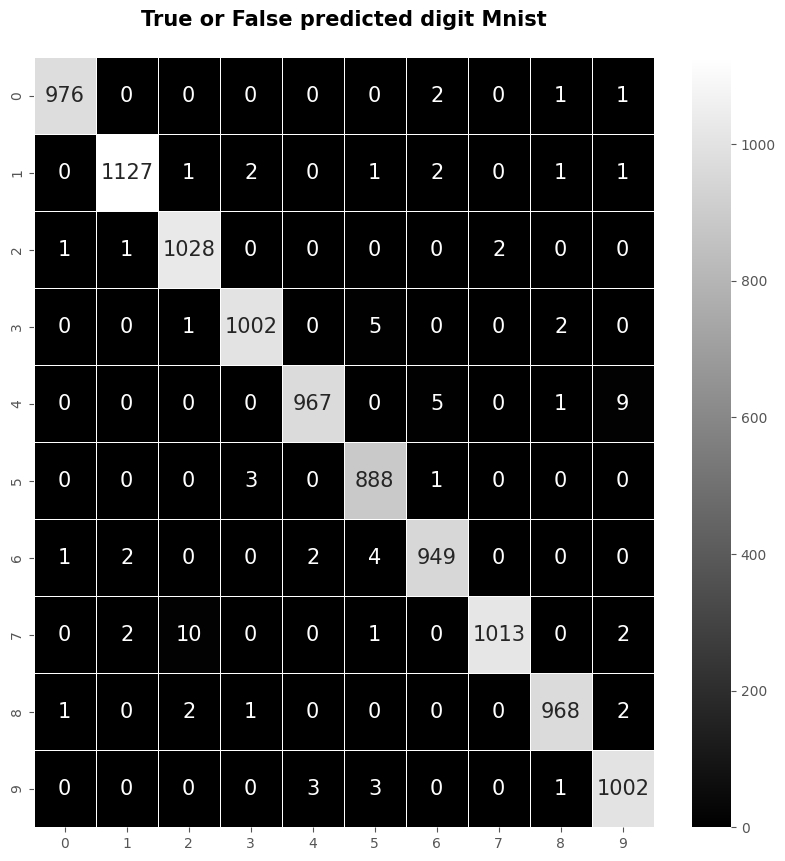

In [31]:
#Confusion matrix for digit mnist
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
con_mat = confusion_matrix(y_test,y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit Mnist\n', fontweight='bold',fontsize=15)
plt.show()

In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predicts))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.98      1.00      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



1/1 [==============================] - 0s 53ms/step
6


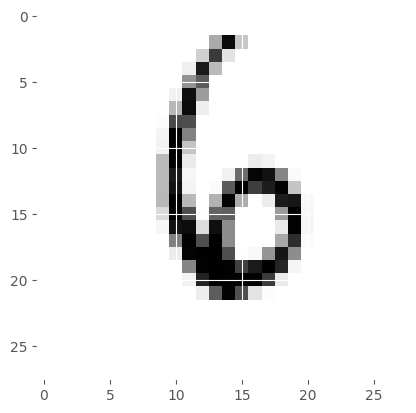

In [34]:
image_index=6900
plt.imshow(x_test[image_index].reshape(28,28),cmap='Grays')
pred = model.predict(x_test[image_index].reshape(1,28,28,1))
predicted_class = np.argmax(pred, axis=1)[0]
print(predicted_class)